# Plotting the sparcity trade-off

Goal plotting the quality/accuracy trade off for different sparcity and amplification values

In [2]:
import sys
sys.path.append('../src')
import utils

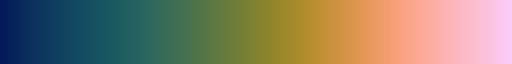

In [3]:
utils.batlow_map

In [4]:
# print(utils.batlow10)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import pandas as pd
from matplotlib.colors import to_rgba
from matplotlib.patches import Ellipse




In [6]:
# -------------------------
# Style (ICML-friendly)
# -------------------------
# plt.rcParams.update({
#     "font.size": 11,
#     "axes.labelsize": 12,
#     "axes.titlesize": 12,
#     "legend.fontsize": 10,
#     "lines.linewidth": 2.0,
#     "lines.markersize": 6,
#     "pdf.fonttype": 42,   # editable text in PDF
#     "ps.fonttype": 42,
# })

plt.rcParams.update({
    # Figure size - ICML typically uses two-column format
    'figure.figsize': (3.25, 2.5),  # Single column width
    # 'figure.figsize': (6.75, 2.5),  # Double column width
    
    # Font sizes
    'font.size': 10,           # Base font size
    'axes.labelsize': 11,      # X and Y labels
    'axes.titlesize': 11,      # Title
    'xtick.labelsize': 9,      # X tick labels
    'ytick.labelsize': 9,      # Y tick labels
    'legend.fontsize': 9,      # Legend
    
    # Font family
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Use LaTeX for text rendering (optional but recommended)
    'text.usetex': False,  # Set to True if you have LaTeX installed
    
    # Line widths
    'axes.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    
    # Grid
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    
    # Ticks
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    
    # Save settings
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'pdf',  # PDF is preferred for publications
})



In [7]:
# WITH REPERTITION PENALTY = 1.1
data = [
    # Quality 1, Quality 2, Token wise Accuracy, sentence wise Accuracy, Noise type, Noise max
    [0.104527, 0.003783, 0.997422, 1.0,      "sparse_0.02", 4],
    [0.232284, 0.091693, 0.992441, 1.0,      "sparse_0.02", 3],
    [0.570377, 0.696684, 0.957594, 0.999646, "sparse_0.02", 2],
    [0.718851, 0.738004, 0.721295, 0.85953,  "sparse_0.02", 1],
    [0.716607, 0.742636, 0.574688, 0.687469, "sparse_0.02", 0.5],
    
    [0.266515, 0.09046, 0.971532, 0.978069,  "sparse_0.01", 4],
    [0.601344, 0.622165, 0.946716, 1.0,      "sparse_0.01", 3],
    [0.693945, 0.751686, 0.780891, 0.921302, "sparse_0.01", 2],
    [0.712895, 0.76087, 0.597991, 0.667173,  "sparse_0.01", 1],
    [0.731681, 0.746497, 0.524466, 0.574177, "sparse_0.01", 0.5],
    
    [0.503513, 0.613531, 0.951771, 1.0,      "sparse_0.005", 4],    
    [0.608165, 0.748048, 0.855827, 0.970241, "sparse_0.005", 3],
    [0.691995, 0.754096, 0.697805, 0.858675, "sparse_0.005", 2],
    [0.719678, 0.734771, 0.563228, 0.618343, "sparse_0.005", 1],
    [0.730355, 0.74151, 0.558619, 0.62768,   "sparse_0.005", 0.5],
        
    [0.53681,  0.674974, 0.914225, 1.0,      "sparse_0.004", 4],
    [0.640986, 0.734481, 0.797332, 0.924197, "sparse_0.004", 3],
    [0.729283, 0.736907, 0.641798, 0.740394, "sparse_0.004", 2],
    [0.731502, 0.722872, 0.539177, 0.587675, "sparse_0.004", 1],
    
    [0.588594, 0.689168, 0.880873, 0.985115, "sparse_0.003", 4],
    [0.696097, 0.726787, 0.766202, 0.892376, "sparse_0.003", 3],
    [0.728785, 0.724989, 0.643508, 0.734861, "sparse_0.003", 2],
    [0.743154, 0.733696, 0.544082, 0.609653, "sparse_0.003", 1],
    [0.742749, 0.738523, 0.509887, 0.516808, "sparse_0.003", 0.5],

    [0.627749, 0.730389, 0.733963, 0.870161, "sparse_0.002", 4],
    [0.710051, 0.738049, 0.6614,   0.756482, "sparse_0.002", 3],
    [0.745275, 0.738622, 0.589836, 0.719911, "sparse_0.002", 2],
    [0.736481, 0.746924, 0.537238, 0.565505, "sparse_0.002", 1],
    
    [0.755555, 0.719951, 0.703347, 0.80936,  "sparse_0.001", 4],
    [0.734603, 0.739241, 0.550369, 0.616149, "sparse_0.001", 1],
    [0.721442, 0.737858, 0.51156,  0.556911, "sparse_0.001", 0.5],
    
    [0.003332, 0.00422,  0.998965, 1.0,      "uniform",      1],
    [0.003536, 0.004763, 0.998516, 1.0,      "uniform",      0.75],
    [0.034298, 0.038691, 0.996559, 1.0,      "uniform",      0.5],
    [0.66543,  0.670497, 0.933683, 1.0,      "uniform",      0.25],
    [0.737349, 0.707607, 0.665297, 0.808489, "uniform",      0.1],
    [0.751517, 0.730348, 0.514471, 0.523346, "uniform",      0.05],
]

In [8]:
# With repetition penalty = 1.0
data = [
    [0.003491, 0.004307, 0.999023, 1.0,      "uniform",      1],
    [0.034389, 0.067308, 0.995504, 1.0,      "uniform",      0.5],
    [0.517184, 0.315277, 0.905276, 0.974388, "uniform",      0.25],
    [0.66459,  0.597683, 0.611807, 0.730131, "uniform",      0.1],
    [0.43834,  0.392308, 0.823611, 0.880273, "sparse_0.003", 4],
    [0.545222, 0.504368, 0.741695, 0.854171, "sparse_0.003", 3],
    [0.615754, 0.612494, 0.647375, 0.711959, "sparse_0.003", 2],
    [0.649293, 0.651057, 0.542472, 0.558728, "sparse_0.003", 1],
]

In [9]:
# Versus vanilla LLM, repetition penalty = 1.0
data = [
    # [0.648127, 0.646549, 0.6567,   0.746692, "uniform",   0.1],
    [0.648127, 0.646549, 0.573891, 0.645414, "uniform",   0.1],
    [0.00403,  0.646549, 0.998965, 1.0,      "uniform",   1],

    [0.435926, 0.646549, 0.858499, 0.944651, "sparse_0.05", 1],
    [0.611643, 0.646549, 0.625368, 0.74626,  "sparse_0.05", 0.5],

    [0.137483, 0.646549, 0.993007, 1.0,      "sparse_0.02", 3],
    [0.314737, 0.646549, 0.942668, 0.998273, "sparse_0.02", 2],
    [0.658484, 0.646549, 0.620916, 0.736123, "sparse_0.02", 1],
    [0.668711, 0.646549, 0.508504, 0.497481, "sparse_0.02", 0.5],

    [0.480427, 0.646549, 0.782306, 0.903799, "sparse_0.003", 4],
    [0.602543, 0.646549, 0.624141, 0.677743, "sparse_0.003", 3],
    [0.635949, 0.646549, 0.569855, 0.671565, "sparse_0.003", 2],
    [0.649262, 0.646549, 0.543454, 0.552026, "sparse_0.003", 1],
    # [0.480427, 0.646549, 0.808025, 0.903718, "sparse_0.003", 4],

    [0.161576, 0.646549, 0.960433, 1.0,      "sparse_0.005", 4],
    [0.389837, 0.646549, 0.864465, 0.937497, "sparse_0.005", 3],
    [0.573467, 0.646549, 0.642483, 0.741527, "sparse_0.005", 2],
    [0.636236, 0.646549, 0.50737,  0.515785, "sparse_0.005", 1],

    [0.602562, 0.646549, 0.756314, 0.839498, "sparse_0.001", 5],
    [0.61293,  0.646549, 0.666309, 0.770503, "sparse_0.001", 4],
    [0.638928, 0.646549, 0.537009, 0.567819, "sparse_0.001", 3],
    [0.663286, 0.646549, 0.50941,  0.566344, "sparse_0.001", 2],
    [0.652166, 0.646549, 0.513312, 0.532738, "sparse_0.001", 1],

]

In [10]:
# Versus Vanilla LLM, repetition penalty = 1.15
data = [
    # [0.003957, 0.674428, 0.999004, 1.0,      "uniform",   1],
    # [0.016683, 0.674428, 0.994057, 1.0,      "uniform",   0.5],

    # o1
    [0.58237,  0.674428, 0.934207, 1.0,      "uniform",   0.25],
    [0.606491, 0.674428, 0.865452, 0.995599, "uniform", 0.2],    
    [0.678633, 0.674428, 0.615709, 0.738332, "uniform",   0.1],
    [0.678935, 0.674428, 0.535039, 0.609532, "uniform", 0.05],
    # o3
    [0.585719, 0.678298, 0.943333, 1, "uniform", 0.25],
    [0.631195, 0.678298, 0.848651, 0.977327, "uniform", 0.2],
    [0.672847, 0.678298, 0.627949, 0.770389, "uniform", 0.1],
    [0.678935, 0.674428, 0.535039, 0.609532, "uniform", 0.05],
    # o2
    [0.264135, 0.69919, 0.935556, 0.998453, "uniform", 0.25],
    [0.408955, 0.69919, 0.84221,  0.994753, "uniform", 0.2],
    [0.655403, 0.69919, 0.593346, 0.688461, "uniform", 0.1],
    [0.691495, 0.69919, 0.564953, 0.615248, "uniform", 0.05],
    # o5
    [0.511292, 0.691688, 0.942527, 1, "uniform", 0.25],
    [0.607626, 0.691688, 0.843097, 0.960238, "uniform", 0.2],
    [0.661549, 0.691688, 0.602379, 0.693885, "uniform", 0.1],
    [0.673807, 0.691688, 0.51013, 0.576729, "uniform", 0.05],
    # o4
    [0.526042, 0.692395, 0.945256, 1, "uniform", 0.25],
    [0.561872, 0.692395, 0.868934, 0.955037, "uniform", 0.2],
    [0.639621, 0.692395, 0.608039, 0.715833, "uniform", 0.1],
    [0.663849, 0.692395, 0.5305, 0.621491, "uniform", 0.05],

    [0.606702, 0.692395, 0.742442, 0.928717, "uniform", 0.15],
    [0.642952, 0.691688, 0.701888, 0.862592, "uniform", 0.15],
    [0.645714, 0.678298, 0.710201, 0.881224, "uniform", 0.15],
    [0.60135, 0.69919, 0.690981, 0.889899, "uniform", 0.15],
    [0.647497, 0.674428, 0.732472, 0.904587, "uniform", 0.15],



    # o1
    [0.557087, 0.674428, 0.919754, 0.979907, "sparse_0.003", 5],
    [0.638192, 0.674428, 0.824839, 0.963857, "sparse_0.003", 4],
    [0.690103, 0.674428, 0.681772, 0.8494,   "sparse_0.003", 3],
    [0.677965, 0.674428, 0.581647, 0.720983, "sparse_0.003", 2],    
    [0.701044, 0.674428, 0.528847, 0.591214, "sparse_0.003", 1],
    # o3
    [0.53001, 0.678298, 0.924208, 1, "sparse_0.003", 5],
    [0.595685, 0.69919, 0.809111, 0.905858, "sparse_0.003", 4],
    [0.61713, 0.69919, 0.675923, 0.738305, "sparse_0.003", 3],
    [0.650409, 0.69919, 0.586755, 0.617271, "sparse_0.003", 2],
    [0.670173, 0.69919, 0.514409, 0.540579, "sparse_0.003", 1],
    # o2
    [0.53001, 0.678298, 0.924208, 1, "sparse_0.003", 5],
    [0.55778, 0.678298, 0.804522, 0.927305, "sparse_0.003", 4],
    [0.616389, 0.678298, 0.65747, 0.759946, "sparse_0.003", 3],
    [0.650389, 0.678298, 0.569749, 0.650548, "sparse_0.003", 2],
    [0.676219, 0.678298, 0.491866, 0.542173, "sparse_0.003", 1],
    # o5
    [0.508234, 0.692395, 0.968436, 1, "sparse_0.003", 5],
    [0.600552, 0.692395, 0.897324, 0.993622, "sparse_0.003", 4],
    [0.661282, 0.692395, 0.734869, 0.939836, "sparse_0.003", 3],
    [0.701549, 0.692395, 0.583284, 0.703158, "sparse_0.003", 2],
    [0.676453, 0.692395, 0.493923, 0.468649, "sparse_0.003", 1],
    # o4
    [0.493314, 0.691688, 0.951074, 1, "sparse_0.003", 5],
    [0.634629, 0.691688, 0.890618, 1, "sparse_0.003", 4],
    [0.641154, 0.691688, 0.75713, 0.931842, "sparse_0.003", 3],
    [0.675804, 0.691688, 0.594043, 0.663627, "sparse_0.003", 2],
    [0.676101, 0.691688, 0.496514, 0.537937, "sparse_0.003", 1]
]

In [11]:
# Vanilla Vs steered, repetition penalty=1.15, Llama3, 1000 sentences
data = [
    # Offset 1 and 2
    # [0.574217, 0.690606, 0.938774, 0.997217, "uniform", 0.25],
    # [0.279393, 0.69624, 0.94942, 1, "uniform", 0.25],

    [0.622352, 0.690606, 0.864311, 0.983017, "uniform", 0.2],
    [0.409923, 0.69624, 0.860933, 0.966707, "uniform", 0.2],

    [0.610476, 0.700655, 0.759454, 0.878606, "uniform", 0.15],
    [0.653246, 0.700646, 0.758285, 0.911568, "uniform", 0.15],
    [0.679921, 0.693564, 0.766937, 0.905648, "uniform", 0.15],
    [0.606732, 0.69624, 0.721954, 0.862316, "uniform", 0.15],
    # [0.654371, 0.690606, 0.749023, 0.921379, "uniform", 0.15],

    [0.67139, 0.69624, 0.605877, 0.717529, "uniform", 0.1],
    [0.68484, 0.690606, 0.639667, 0.770254, "uniform", 0.1],

    [0.690967, 0.69624, 0.529337, 0.55484, "uniform", 0.05],
    [0.688122, 0.690606, 0.515208, 0.523612, "uniform", 0.05],
    [0.558222, 0.700655, 0.883028, 0.987757, "uniform", 0.2],
    [0.651795, 0.700655, 0.617112, 0.70321, "uniform", 0.1],
    [0.612278, 0.700646, 0.878438, 0.985928, "uniform", 0.2],
    [0.675731, 0.700646, 0.627828, 0.761643, "uniform", 0.1],

# Offset 3 and 4
    [0.685288, 0.690606, 0.729834, 0.874105, "sparse_0.003", 3],
    [0.69077, 0.690606, 0.587091, 0.687681, "sparse_0.003", 2],
    [0.598174, 0.69624, 0.855446, 0.964761, "sparse_0.003", 4],
    [0.629679, 0.69624, 0.745535, 0.860815, "sparse_0.003", 3],
    [0.660185, 0.69624, 0.620066, 0.716313, "sparse_0.003", 2],
    [0.640138, 0.690606, 0.854852, 0.974262, "sparse_0.003", 4],

# Noise offset 4 and 5
    [0.511779, 0.700655, 0.971544, 1, "sparse_0.003", 5],
    [0.608165, 0.700655, 0.917036, 0.991702, "sparse_0.003", 4],
    [0.680663, 0.700655, 0.800983, 0.91135, "sparse_0.003", 3],
    [0.698807, 0.700655, 0.644829, 0.760038, "sparse_0.003", 2],
    [0.700134, 0.700655, 0.563533, 0.636449, "sparse_0.003", 1],
    [0.489794, 0.700646, 0.963237, 0.996391, "sparse_0.003", 5],
    [0.626837, 0.700646, 0.902717, 0.989335, "sparse_0.003", 4],
    [0.652104, 0.700646, 0.790258, 0.937137, "sparse_0.003", 3],
    [0.682835, 0.700646, 0.630126, 0.735897, "sparse_0.003", 2],
    [0.701474, 0.700646, 0.538617, 0.592221, "sparse_0.003", 1],

]

In [12]:
# # Yet a new compilation of results. This time with Llama3.1-8B. repetition penalty = 1.1, guardian=1000
# data = [
#     # Sparse
#     [0.745815, 0.707797, 0.885794, 0.985569, "sparse_0.003", 5],
#     [0.69805, 0.735841, 0.825463, 0.963229, "sparse_0.003", 5],
#     [0.72373, 0.711148, 0.79673, 0.93586, "sparse_0.003", 5],
#     [0.741166, 0.758431, 0.804862, 0.931256, "sparse_0.003", 5],
#     [0.620891, 0.716441, 0.905004, 0.99119, "sparse_0.003", 5],

#     # o0 & o1
#     [0.755031, 0.763358, 0.727499, 0.849741, "sparse_0.003", 4],
#     [0.759155, 0.770534, 0.6319, 0.712909, "sparse_0.003", 3],
#     [0.766386, 0.764498, 0.578284, 0.647569, "sparse_0.003", 2],
#     [0.760589, 0.762005, 0.52988, 0.573108, "sparse_0.003", 1],
#     [0.707048, 0.749675, 0.822129, 0.955302, "sparse_0.003", 4],
#     [0.748164, 0.75433, 0.705157, 0.889042, "sparse_0.003", 3],
#     [0.762711, 0.757145, 0.620408, 0.700816, "sparse_0.003", 2],
#     [0.763469, 0.754939, 0.541646, 0.577398, "sparse_0.003", 1],
#     # o2
#     [0.740481, 0.734268, 0.72563, 0.856631, "sparse_0.003", 4],
#     # need rerun of maxnoise 3
#     [0.757599, 0.756789, 0.586205, 0.672906, "sparse_0.003", 2],
#     [0.758316, 0.753402, 0.525459, 0.561877, "sparse_0.003", 1],
#     # o3
#     [0.724847, 0.751162, 0.74512, 0.881369, "sparse_0.003", 4],
#     [0.738462, 0.763763, 0.663607, 0.800462, "sparse_0.003", 3],
#     [0.739268, 0.762653, 0.595028, 0.665911, "sparse_0.003", 2],
#     [0.75125, 0.753243, 0.518102, 0.570529, "sparse_0.003", 1],
#     # o4
#     [0.761663, 0.745003, 0.715256, 0.833576, "sparse_0.003", 3],
#     [0.764098, 0.749307, 0.613958, 0.672783, "sparse_0.003", 2],
#     [0.757666, 0.758138, 0.538467, 0.575266, "sparse_0.003", 1],



#     # Unif

#     [0.732794, 0.726765, 0.869128, 0.973447, "uniform", 0.25],

#     # o1, 2, 3
#     [0.740917, 0.760679, 0.813612, 0.95471, "uniform", 0.2],
#     [0.720991, 0.728273, 0.796421, 0.926284, "uniform", 0.2],
#     [0.742619, 0.76182, 0.833602, 0.952577, "uniform", 0.2],
#     [0.750868, 0.737641, 0.811682, 0.930482, "uniform", 0.2],

#     [0.753681, 0.733258, 0.67157, 0.804704, "uniform", 0.15],
#     [0.756743, 0.757846, 0.733523, 0.902799, "uniform", 0.15],
#     [0.751642, 0.733226, 0.73199, 0.848555, "uniform", 0.15],
#     [0.753525, 0.760049, 0.743123, 0.867584, "uniform", 0.15],
#     [0.751261, 0.746729, 0.729399, 0.848093, "uniform", 0.15],

#     [0.756842, 0.755631, 0.626685, 0.734673, "uniform", 0.1],
#     [0.763703, 0.744338, 0.630915, 0.734445, "uniform", 0.1],
#     [0.761982, 0.751518, 0.626278, 0.741824, "uniform", 0.1],

#     [0.756686, 0.755371, 0.528348, 0.539414, "uniform", 0.05],
#     [0.757625, 0.758174, 0.538918, 0.595492, "uniform", 0.05],
#     [0.760163, 0.749028, 0.529295, 0.56605, "uniform", 0.05],
#     [0.760273, 0.75874, 0.546651, 0.603608, "uniform", 0.05],

# ]

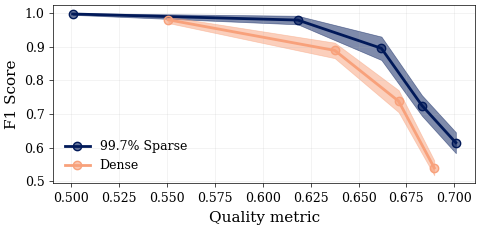

In [ ]:
# -------------------------
# Data (REPLACE with yours)
# -------------------------
# Sparsity levels
# sparsities = [0.001, 0.003, 0.005, 0.01, 0.02, 0.05, 1.0]
sparsities = [0.003, 1.0]

# For each sparsity: (quality, accuracy) points according to the amplification value
# Shape: {sparsity: (quality_array, accuracy_array)}


df = pd.DataFrame(
    data,
    columns=[
        "Quality 1",
        "Quality 2",
        "Token wise Accuracy",
        "sentence wise Accuracy",
        "Noise type",
        "Noise max",
    ],
)


# -------------------------
# Colormap: batlow
# -------------------------
# batlow = utils.batlow_map #get_cmap("batlow")
# colors = batlow(np.linspace(0.1, 0.9, len(sparsities)))

colors = utils.batlow_categorical_colors
colors = utils.batlow10_colors

# Select 6 from the 10 available
color_sets = {
    2: [0, 7],
    7: [0, 2, 4, 5, 6, 8, 9],
}
colors = [colors[i] for i in color_sets[len(sparsities)]]

def sparcity_label(s):
    if s == 1.0:
        return "Dense"
    else:
        return f"{(1-s)*100}% Sparse"

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(5.0, 2.5))

for i, sparsity in enumerate(sparsities):
    subset = df[df["Noise type"] == f"sparse_{sparsity}"] if sparsity != 1.0 else df[df["Noise type"] == "uniform"]
    
    # Group by "Noise max" and compute mean and std
    grouped = subset.groupby("Noise max").agg({
        "Quality 1": ["mean", "std"],
        "sentence wise Accuracy": ["mean", "std"],
        "Token wise Accuracy": ["mean", "std"],
    }).reset_index()
    
    # Extract values
    noise_max = grouped["Noise max"].values
    quality_mean = grouped["Quality 1"]["mean"].values
    quality_std = grouped["Quality 1"]["std"].values

    # accuracy_mean = grouped["Token wise Accuracy"]["mean"].values
    # accuracy_std = grouped["Token wise Accuracy"]["std"].values
    accuracy_mean = grouped["sentence wise Accuracy"]["mean"].values
    accuracy_std = grouped["sentence wise Accuracy"]["std"].values
    
    # Handle NaN std (when only 1 sample per group)
    quality_std = np.nan_to_num(quality_std, nan=0.0)
    accuracy_std = np.nan_to_num(accuracy_std, nan=0.0)
    
    marker_color = to_rgba(colors[i], alpha=0.6)
    
    # Plot the line
    ax.plot(
        quality_mean,
        accuracy_mean,
        marker="o",
        color=colors[i],
        label=sparcity_label(sparsity),
        markerfacecolor=marker_color,
        markeredgecolor=colors[i],
        markersize=6,
        linewidth=2,
        zorder=3,
    )
    
    # Add shaded area for standard deviation
    ax.fill_between(
        quality_mean,
        accuracy_mean - accuracy_std,
        accuracy_mean + accuracy_std,
        color=colors[i],
        alpha=0.5,
        zorder=1,
    )

# Labels
ax.set_xlabel("Quality metric")
ax.set_ylabel("F1 Score")

# Optional: tighten limits if needed
# ax.set_xlim(left=0.6)
# ax.set_ylim(0.8, 1.05)

# Grid (very light, ICML-style)
ax.grid(True, alpha=0.2)

# Legend
ax.legend(frameon=False, ncol=1)

# Layout
fig.tight_layout()

# -------------------------
# Save to PDF (ICML-ready)
# -------------------------
plt.savefig("sparsity_quality_accuracy_thiner.pdf", bbox_inches="tight")
plt.show()